# MosBeatNetV2 Compression Analysis

Analysis-only notebook for:

- FP32 baseline
- Dynamic INT8 (`Linear + LSTM`)
- Global unstructured pruning: 10%, 20%, 30%, 40%, 50%
- Pruning + INT8
- Actual pruning sparsity and effective non-zero parameters
- In-memory serialized state size
- CPU latency, speedup, and throughput
- Macro-F1 by environment
- Full evaluation time
- Trade-off tables and plots

**This notebook does not export models, CSV results, or evaluation folders.**

The project data pipeline may still require a temporary workspace while constructing datasets. That workspace is created with `tempfile` and is not used as a compression-result directory.


## 1. Imports and project path


In [1]:
import os
import sys
import io
import time
import copy
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = PACKAGE_DIR = None

for candidate in [cwd, cwd.parent, cwd.parent.parent]:
    package_dir = candidate / "package"
    required = ["main.py", "config.py", "evaluate.py", "model.py"]

    if package_dir.is_dir() and all((package_dir / f).is_file() for f in required):
        PROJECT_ROOT, PACKAGE_DIR = candidate, package_dir
        break

if PROJECT_ROOT is None:
    raise RuntimeError(f"Cannot locate mosbeatnet_main/package from {cwd}")

for path in [str(PACKAGE_DIR), str(PROJECT_ROOT)]:
    if path not in sys.path:
        sys.path.insert(0, path)

import config
from model import MosbeatnetV2

from main import (
    build_eval_csv_map,
    get_eval_definition,
    make_eval_dataset,
    make_loader,
    remap_predictions,
    checkpoint_state_dict,
)

from evaluate import (
    get_model_predictions,
    evaluate_segment_classification,
    value_from_metric_df,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PACKAGE_DIR :", PACKAGE_DIR)
print("PyTorch     :", torch.__version__)


PROJECT_ROOT: /home/mosbnet/mosdet/mosbeatnet_main
PACKAGE_DIR : /home/mosbnet/mosdet/mosbeatnet_main/package
PyTorch     : 2.5.1+cu121


/home/mosbnet/miniconda3/envs/mosbeatnet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Settings


In [2]:
# CHANGE THIS ONLY IF YOUR CHECKPOINT MOVED
CHECKPOINT_PATH = "/home/mosbnet/mosdet/mosbeatnet_main/output/xdomain_exp6_all_sources_sp5/mosbeatnet_v2/seed_42/run_20260905T160309Z_cfg9a9c6971_gita88b856/checkpoints/best_macro_f1.pt"

PRUNE_LEVELS = [0.10, 0.20, 0.30, 0.40, 0.50]

WARMUP_RUNS = 10
LATENCY_RUNS = 50
SEED = 42

# True = FP32 + INT8 + all pruning variants
# False = FP32 + INT8 only
RUN_ALL_VARIANTS = True

# Used only by the automatic "acceptable F1 drop" summary.
# 0.01 means an absolute Macro-F1 drop of at most 0.01.
F1_TOLERANCE = 0.01

torch.manual_seed(SEED)
np.random.seed(SEED)

print("Pruning levels :", PRUNE_LEVELS)
print("Latency runs   :", LATENCY_RUNS)
print("Run all models :", RUN_ALL_VARIANTS)


Pruning levels : [0.1, 0.2, 0.3, 0.4, 0.5]
Latency runs   : 50
Run all models : True


## 3. Load FP32 checkpoint


In [3]:
CHECKPOINT_PATH = os.path.abspath(os.path.expanduser(CHECKPOINT_PATH))

if not os.path.isfile(CHECKPOINT_PATH):
    raise FileNotFoundError(CHECKPOINT_PATH)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("model_key   :", checkpoint.get("model_key"))
print("model_name  :", checkpoint.get("model_name"))
print("epoch       :", checkpoint.get("epoch"))
print("val_f1_macro:", checkpoint.get("val_f1_macro"))
print("model_kwargs:", checkpoint.get("model_kwargs"))

model_kwargs = checkpoint.get("model_kwargs")
if model_kwargs is None:
    raise KeyError("Checkpoint does not contain model_kwargs")

model_fp32 = MosbeatnetV2(**model_kwargs)
state_dict = checkpoint_state_dict(checkpoint)

clean_state = {}

for key, value in state_dict.items():
    new_key = key

    for prefix in ("module.", "_orig_mod.", "model."):
        if new_key.startswith(prefix):
            new_key = new_key[len(prefix):]

    clean_state[new_key] = value

check = model_fp32.load_state_dict(clean_state, strict=False)

print("Missing keys   :", check.missing_keys)
print("Unexpected keys:", check.unexpected_keys)

if check.missing_keys or check.unexpected_keys:
    raise RuntimeError("Checkpoint/model architecture mismatch")

model_fp32.load_state_dict(clean_state, strict=True)
model_fp32 = model_fp32.cpu().eval()

TOTAL_PARAMS = sum(p.numel() for p in model_fp32.parameters())

print("\nFP32 loaded")
print(f"Parameters: {TOTAL_PARAMS:,}")
print(f"Parameters: {TOTAL_PARAMS / 1e6:.6f} M")


model_key   : mosbeatnet_v2
model_name  : MosbeatnetV2
epoch       : 32
val_f1_macro: 0.7774079684904274
model_kwargs: {'n_timesteps': 4000, 'n_outputs': 5}
Missing keys   : []
Unexpected keys: []

FP32 loaded
Parameters: 512,742
Parameters: 0.512742 M


## 4. Recover experiment configuration


In [4]:
resolved_config = checkpoint.get("resolved_config")

if not resolved_config or "experiment" not in resolved_config:
    raise KeyError("Checkpoint does not contain resolved_config['experiment']")

exp_cfg = copy.deepcopy(resolved_config["experiment"])

model_label_map = checkpoint.get("label_map")
if model_label_map is None:
    raise KeyError("Checkpoint does not contain label_map")


def restore_path(path):
    path = os.path.expanduser(os.fspath(path))

    if os.path.isabs(path):
        return os.path.abspath(path)

    return os.path.abspath(str(PROJECT_ROOT / path))


for key in ("train_csvs", "val_csvs"):
    if key in exp_cfg:
        values = exp_cfg[key] if isinstance(exp_cfg[key], (list, tuple)) else [exp_cfg[key]]
        exp_cfg[key] = [restore_path(x) for x in values]


for tag, spec in exp_cfg["eval_sets"].items():
    values = spec.get("csvs", [])
    values = values if isinstance(values, (list, tuple)) else [values]
    spec["csvs"] = [restore_path(x) for x in values]


# Some project helpers expect output/cache paths even though this notebook
# does not keep compression outputs. Use one temporary workspace only.
TEMP_WORKSPACE = tempfile.TemporaryDirectory(prefix="mosbeatnet_compression_")
TMP_ROOT = Path(TEMP_WORKSPACE.name)

WORK_DIR = TMP_ROOT / "workspace"
CSV_DIR = WORK_DIR / "csv"
SEG_DIR = WORK_DIR / "segment_cache"
EVAL_DIR = WORK_DIR / "evaluation"

for directory in [WORK_DIR, CSV_DIR, SEG_DIR, EVAL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

exp_cfg["output"] = {
    "base": str(WORK_DIR),
    "model_dir": str(WORK_DIR / "checkpoints"),
    "eval_dir": str(EVAL_DIR),
    "run_dir": str(WORK_DIR / "tensorboard"),
    "csv_dir": str(CSV_DIR),
    "seg_dir": str(SEG_DIR),
}

print("Experiment :", exp_cfg.get("exp_name"))
print("Target type:", exp_cfg.get("target_type"))
print("Segment sec:", exp_cfg.get("seg_sec"))
print("Batch size :", exp_cfg.get("batch"))
print("Workers    :", exp_cfg.get("workers"))
print("Label map  :", model_label_map)
print("Temporary workspace only:", TMP_ROOT)


Experiment : xdomain_exp6_all_sources_sp5
Target type: species
Segment sec: 0.5
Batch size : 64
Workers    : 4
Label map  : {'Noise': 0, 'Ae.Aegypti': 1, 'Ae.Albopictus': 2, 'An.Dirus': 3, 'Cx.Quin': 4}
Temporary workspace only: /tmp/mosbeatnet_compression_2mt4k42w


## 5. Build evaluation DataLoaders


In [5]:
eval_csv_map = build_eval_csv_map(exp_cfg)
EVAL_SPECS = {}

for tag, info in eval_csv_map.items():
    test_csv = info["csv"]
    label_space = info["label_space"]

    label_mode, eval_label_map = get_eval_definition(
        exp_cfg,
        label_space,
    )

    dataset = make_eval_dataset(
        test_csv=test_csv,
        exp_cfg=exp_cfg,
        eval_label_map=eval_label_map,
        label_mode=label_mode,
        tag=tag,
    )

    loader = make_loader(
        dataset,
        exp_cfg,
        shuffle=False,
    )

    EVAL_SPECS[tag] = {
        "loader": loader,
        "dataset": dataset,
        "csv": test_csv,
        "label_space": label_space,
        "label_mode": label_mode,
        "label_map": eval_label_map,
    }


if not EVAL_SPECS:
    raise RuntimeError("No evaluation loaders created")


rows = []

for tag, spec in EVAL_SPECS.items():
    rows.append({
        "Environment": tag,
        "Samples": len(spec["dataset"]),
        "Batches": len(spec["loader"]),
        "Label Space": spec["label_space"],
    })

eval_overview_df = pd.DataFrame(rows)
display(eval_overview_df)


FIRST_TAG = next(iter(EVAL_SPECS))
FIRST_LOADER = EVAL_SPECS[FIRST_TAG]["loader"]

batch = next(iter(FIRST_LOADER))
sample_x = batch[0].cpu()
sample_y = batch[1].cpu()

with torch.inference_mode():
    sample_out = model_fp32(sample_x)

N_CLASSES = sample_out.shape[-1]

print("First environment:", FIRST_TAG)
print("Input :", tuple(sample_x.shape))
print("Target:", tuple(sample_y.shape))
print("Output:", tuple(sample_out.shape))


[merge] 1 files, 18044 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_indoor_urban.csv
[merge] 1 files, 17940 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_indoor_forest.csv
[merge] 1 files, 17993 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_outdoor_gaussian.csv
[merge] 1 files, 17986 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_humbug_urban.csv
[merge] 1 files, 17921 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_humbug_forest.csv
[merge] 1 files, 50578 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_biodcase_urban.csv
[merge] 1 files, 50243 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_biodcase_forest.csv
[merge] 2 files, 1000 rows -> /tmp/mosbeatnet_compression_2mt4k42w/workspace/csv/test_noise_only.csv
[Dataset] Preparing labels for 2250 files...
[Dataset] Preparing labels for 2250 files...
[Dataset] Preparing labels for 2250 files...
[Dataset] Preparing label

,Environment,Samples,Batches,Label Space
0,indoor_urban,2250,36,species
1,indoor_forest,2250,36,species
2,outdoor_gaussian,2250,36,species
3,humbug_urban,2250,36,species
4,humbug_forest,2250,36,species
5,biodcase_urban,6000,94,species
6,biodcase_forest,6000,94,species
7,noise_only,1000,16,species


First environment: indoor_urban
Input : (64, 20, 1, 4000)
Target: (64, 20)
Output: (64, 20, 5)


## 6. Compression utilities

### Why pruning may not reduce the saved state size

The pruning used here is **unstructured pruning**. After `prune.remove(...)`, the selected weights become exact zeros, but the tensor is still stored as a normal dense tensor. Therefore:

- sparsity increases,
- the number of effective non-zero weights decreases,
- but the dense FP32 state size can remain almost unchanged,
- and dense CPU inference may not become faster without sparse kernels.

For that reason this notebook reports both **physical state size** and **effective parameters**.


In [6]:
def serialized_size_mb(model):
    # Serialize state_dict to RAM only. No file is written.
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return len(buffer.getvalue()) / (1024 ** 2)


def get_prunable_params(model):
    targets = []

    for module in model.modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            targets.append((module, "weight"))

        elif isinstance(module, nn.LSTM):
            for name, _ in module.named_parameters(recurse=False):
                if name.startswith(("weight_ih", "weight_hh")):
                    targets.append((module, name))

    return targets


def get_pruning_stats(model):
    zero_weights = 0
    prunable_weights = 0

    for module, name in get_prunable_params(model):
        weight = getattr(module, name).detach()
        zero_weights += int((weight == 0).sum().item())
        prunable_weights += int(weight.numel())

    sparsity = zero_weights / prunable_weights if prunable_weights else np.nan

    return {
        "zero_prunable": zero_weights,
        "prunable_total": prunable_weights,
        "sparsity": sparsity,
    }


def prune_model(model, amount):
    pruned_model = copy.deepcopy(model).cpu().eval()
    targets = get_prunable_params(pruned_model)

    prune.global_unstructured(
        targets,
        pruning_method=prune.L1Unstructured,
        amount=float(amount),
    )

    # Make the zeros permanent and remove weight_orig / weight_mask.
    for module, name in targets:
        prune.remove(module, name)

    return pruned_model


def dynamic_int8(model):
    quant_model = copy.deepcopy(model).cpu().eval()

    try:
        quant_model = torch.ao.quantization.quantize_dynamic(
            quant_model,
            {nn.Linear, nn.LSTM},
            dtype=torch.qint8,
            inplace=False,
        )
    except Exception:
        quant_model = torch.quantization.quantize_dynamic(
            quant_model,
            {nn.Linear, nn.LSTM},
            dtype=torch.qint8,
            inplace=False,
        )

    return quant_model.cpu().eval()


def measure_cpu_latency(model, x, warmup=WARMUP_RUNS, runs=LATENCY_RUNS):
    model = model.cpu().eval()
    x = x[:1].cpu()

    with torch.inference_mode():
        for _ in range(warmup):
            model(x)

        times_ms = []

        for _ in range(runs):
            start = time.perf_counter()
            model(x)
            times_ms.append((time.perf_counter() - start) * 1000)

    mean_ms = float(np.mean(times_ms))

    return {
        "mean": mean_ms,
        "std": float(np.std(times_ms)),
        "median": float(np.median(times_ms)),
        "p95": float(np.percentile(times_ms, 95)),
        "throughput": 1000.0 / mean_ms if mean_ms > 0 else np.nan,
    }


## 7. Build compression variants


In [7]:
variants = {}
variant_meta = {}


def add_variant(name, model, pruning, quantization, pruning_source):
    stats = get_pruning_stats(pruning_source)

    variants[name] = model.cpu().eval()
    variant_meta[name] = {
        "Pruning (%)": float(pruning) * 100.0,
        "Quantization": quantization,
        "Zero Prunable Weights": stats["zero_prunable"],
        "Prunable Weights": stats["prunable_total"],
        "Prunable Sparsity (%)": stats["sparsity"] * 100.0,
        "Effective Params": TOTAL_PARAMS - stats["zero_prunable"],
    }


add_variant(
    "FP32",
    copy.deepcopy(model_fp32),
    pruning=0.0,
    quantization="None",
    pruning_source=model_fp32,
)

add_variant(
    "INT8_dynamic",
    dynamic_int8(model_fp32),
    pruning=0.0,
    quantization="Dynamic INT8",
    pruning_source=model_fp32,
)


for amount in PRUNE_LEVELS:
    pct = int(round(amount * 100))
    pruned = prune_model(model_fp32, amount)

    add_variant(
        f"Prune_{pct}",
        pruned,
        pruning=amount,
        quantization="None",
        pruning_source=pruned,
    )

    add_variant(
        f"Prune_{pct}_INT8",
        dynamic_int8(pruned),
        pruning=amount,
        quantization="Dynamic INT8",
        pruning_source=pruned,
    )


variant_df = pd.DataFrame([
    {
        "Variant": name,
        **meta,
        "Nominal Params": TOTAL_PARAMS,
        "Effective Param Reduction (%)":
            100.0 * (TOTAL_PARAMS - meta["Effective Params"]) / TOTAL_PARAMS,
    }
    for name, meta in variant_meta.items()
])

display(
    variant_df[
        [
            "Variant",
            "Pruning (%)",
            "Quantization",
            "Prunable Sparsity (%)",
            "Nominal Params",
            "Effective Params",
            "Effective Param Reduction (%)",
        ]
    ].round(4)
)


,Variant,Pruning (%),Quantization,Prunable Sparsity (%),Nominal Params,Effective Params,Effective Param Reduction (%)
0,FP32,0.0,None,0.0000,512742,512742,0.0000
1,INT8_dynamic,0.0,Dynamic INT8,0.0000,512742,512742,0.0000
2,Prune_10,10.0,None,10.0000,512742,461865,9.9225
3,Prune_10_INT8,10.0,Dynamic INT8,10.0000,512742,461865,9.9225
4,Prune_20,20.0,None,20.0001,512742,410988,19.8451
5,Prune_20_INT8,20.0,Dynamic INT8,20.0001,512742,410988,19.8451
6,Prune_30,30.0,None,29.9999,512742,360112,29.7674
7,Prune_30_INT8,30.0,Dynamic INT8,29.9999,512742,360112,29.7674
8,Prune_40,40.0,None,40.0000,512742,309235,39.6899
9,Prune_40_INT8,40.0,Dynamic INT8,40.0000,512742,309235,39.6899


## 8. Output shape sanity check


In [8]:
expected_shape = tuple(sample_y.shape) + (N_CLASSES,)
rows = []

for name, model in variants.items():
    try:
        with torch.inference_mode():
            output = model(sample_x)

        shape = tuple(output.shape)

        rows.append({
            "Variant": name,
            "Output Shape": shape,
            "Pass": shape == expected_shape,
            "Error": "",
        })

    except Exception as exc:
        rows.append({
            "Variant": name,
            "Output Shape": None,
            "Pass": False,
            "Error": repr(exc),
        })


shape_df = pd.DataFrame(rows)
display(shape_df)

if not shape_df["Pass"].all():
    raise RuntimeError("At least one compression variant has invalid output shape")

print("All variants passed the output-shape check.")


,Variant,Output Shape,Pass,Error
0,FP32,"(64, 20, 5)",True,
1,INT8_dynamic,"(64, 20, 5)",True,
2,Prune_10,"(64, 20, 5)",True,
3,Prune_10_INT8,"(64, 20, 5)",True,
4,Prune_20,"(64, 20, 5)",True,
5,Prune_20_INT8,"(64, 20, 5)",True,
6,Prune_30,"(64, 20, 5)",True,
7,Prune_30_INT8,"(64, 20, 5)",True,
8,Prune_40,"(64, 20, 5)",True,
9,Prune_40_INT8,"(64, 20, 5)",True,


All variants passed the output-shape check.


## 9. Size, sparsity, latency, speedup and throughput


In [9]:
benchmark_rows = []

for name, model in variants.items():
    print("Benchmark:", name)

    latency = measure_cpu_latency(model, sample_x)
    meta = variant_meta[name]

    benchmark_rows.append({
        "Variant": name,
        "Pruning (%)": meta["Pruning (%)"],
        "Quantization": meta["Quantization"],
        "Nominal Params (M)": TOTAL_PARAMS / 1e6,
        "Effective Params (M)": meta["Effective Params"] / 1e6,
        "Effective Param Reduction (%)":
            100.0 * (TOTAL_PARAMS - meta["Effective Params"]) / TOTAL_PARAMS,
        "Prunable Sparsity (%)": meta["Prunable Sparsity (%)"],
        "State Size (MB)": serialized_size_mb(model),
        "CPU Mean (ms)": latency["mean"],
        "CPU Std (ms)": latency["std"],
        "CPU Median (ms)": latency["median"],
        "CPU P95 (ms)": latency["p95"],
        "Single-sample Throughput (samples/s)": latency["throughput"],
    })


benchmark_df = pd.DataFrame(benchmark_rows)

fp32_latency = benchmark_df.loc[
    benchmark_df["Variant"] == "FP32", "CPU Mean (ms)"
].iloc[0]

fp32_size = benchmark_df.loc[
    benchmark_df["Variant"] == "FP32", "State Size (MB)"
].iloc[0]

benchmark_df["Speedup (x)"] = fp32_latency / benchmark_df["CPU Mean (ms)"]

benchmark_df["Latency Reduction (%)"] = (
    100.0 * (fp32_latency - benchmark_df["CPU Mean (ms)"]) / fp32_latency
)

benchmark_df["Size Reduction (%)"] = (
    100.0 * (fp32_size - benchmark_df["State Size (MB)"]) / fp32_size
)

display(
    benchmark_df[
        [
            "Variant",
            "Pruning (%)",
            "Quantization",
            "Prunable Sparsity (%)",
            "Effective Param Reduction (%)",
            "State Size (MB)",
            "Size Reduction (%)",
            "CPU Mean (ms)",
            "CPU P95 (ms)",
            "Speedup (x)",
            "Single-sample Throughput (samples/s)",
        ]
    ].round(4)
)


Benchmark: FP32
Benchmark: INT8_dynamic
Benchmark: Prune_10
Benchmark: Prune_10_INT8
Benchmark: Prune_20
Benchmark: Prune_20_INT8
Benchmark: Prune_30
Benchmark: Prune_30_INT8
Benchmark: Prune_40
Benchmark: Prune_40_INT8
Benchmark: Prune_50
Benchmark: Prune_50_INT8


,Variant,Pruning (%),Quantization,Prunable Sparsity (%),Effective Param Reduction (%),State Size (MB),Size Reduction (%),CPU Mean (ms),CPU P95 (ms),Speedup (x),Single-sample Throughput (samples/s)
0,FP32,0.0,None,0.0000,0.0000,1.9819,0.0000,6.4266,6.9902,1.0000,155.6037
1,INT8_dynamic,0.0,Dynamic INT8,0.0000,0.0000,1.2330,37.7859,7.8971,8.2128,0.8138,126.6293
2,Prune_10,10.0,None,10.0000,9.9225,1.9818,0.0031,7.0599,7.2247,0.9103,141.6450
3,Prune_10_INT8,10.0,Dynamic INT8,10.0000,9.9225,1.2330,37.7859,5.8124,5.9113,1.1057,172.0461
4,Prune_20,20.0,None,20.0001,19.8451,1.9818,0.0031,8.6259,6.6157,0.7450,115.9305
5,Prune_20_INT8,20.0,Dynamic INT8,20.0001,19.8451,1.2330,37.7859,5.9766,6.0568,1.0753,167.3200
6,Prune_30,30.0,None,29.9999,29.7674,1.9818,0.0031,6.3607,6.7190,1.0104,157.2153
7,Prune_30_INT8,30.0,Dynamic INT8,29.9999,29.7674,1.2330,37.7859,5.9963,6.0878,1.0718,166.7687
8,Prune_40,40.0,None,40.0000,39.6899,1.9818,0.0031,6.6686,7.2338,0.9637,149.9575
9,Prune_40_INT8,40.0,Dynamic INT8,40.0000,39.6899,1.2330,37.7859,8.0700,8.3082,0.7964,123.9165


## 10. In-memory evaluation helpers

The original notebook used saved evaluation folders and then called `build_all_domains_evaluation()`.

This version keeps predictions and metrics in memory. It reports:

- Macro-F1 for each environment,
- mean environment Macro-F1,
- segment-weighted mean environment Macro-F1,
- true pooled Macro-F1 **only when all evaluation sets use the same label space and label map**,
- inference time and total evaluation time.

When label spaces differ, predictions are **not** silently concatenated.


In [10]:
def evaluate_one_environment_in_memory(model, tag, spec):
    model = model.cpu().eval()

    total_start = time.perf_counter()
    inference_start = time.perf_counter()

    raw_pred, y_true, _ = get_model_predictions(
        model,
        spec["loader"],
        torch.device("cpu"),
    )

    inference_seconds = time.perf_counter() - inference_start

    y_pred = remap_predictions(
        raw_pred,
        model_label_map,
        spec["label_map"],
        spec["label_space"],
        exp_cfg["target_type"],
    )

    y_true = np.asarray(y_true).reshape(-1).astype(np.int64, copy=False)
    y_pred = np.asarray(y_pred).reshape(-1).astype(np.int64, copy=False)

    results_df, class_df = evaluate_segment_classification(
        y_pred=y_pred,
        y_true=y_true,
        label_dict=spec["label_map"],
        save=False,
    )

    macro_f1 = float(
        value_from_metric_df(results_df, "Macro F1-score")
    )

    total_seconds = time.perf_counter() - total_start

    return {
        "Environment": tag,
        "Macro-F1": macro_f1,
        "N(segment)": len(y_true),
        "Inference Time (s)": inference_seconds,
        "Environment Eval Time (s)": total_seconds,
        "y_true": y_true,
        "y_pred": y_pred,
        "label_space": spec["label_space"],
        "label_map": spec["label_map"],
        "results": results_df,
        "class_report": class_df,
    }


def environments_can_be_pooled(environment_results):
    if not environment_results:
        return False

    first = environment_results[0]

    for result in environment_results[1:]:
        if result["label_space"] != first["label_space"]:
            return False

        if result["label_map"] != first["label_map"]:
            return False

    return True


def evaluate_variant_in_memory(name, model):
    variant_start = time.perf_counter()
    environment_results = []

    for tag, spec in EVAL_SPECS.items():
        print(f"[{name}] {tag}")

        environment_results.append(
            evaluate_one_environment_in_memory(
                model=model,
                tag=tag,
                spec=spec,
            )
        )

    full_eval_seconds = time.perf_counter() - variant_start

    macro_f1_values = np.asarray([
        r["Macro-F1"] for r in environment_results
    ], dtype=float)

    segment_counts = np.asarray([
        r["N(segment)"] for r in environment_results
    ], dtype=float)

    total_segments = int(segment_counts.sum())
    total_inference_seconds = float(sum(
        r["Inference Time (s)"] for r in environment_results
    ))

    mean_env_f1 = float(np.mean(macro_f1_values))

    weighted_env_f1 = float(
        np.average(macro_f1_values, weights=segment_counts)
    )

    pooled_f1 = np.nan
    pooled_valid = environments_can_be_pooled(environment_results)

    if pooled_valid:
        pooled_y_true = np.concatenate([
            r["y_true"] for r in environment_results
        ])

        pooled_y_pred = np.concatenate([
            r["y_pred"] for r in environment_results
        ])

        pooled_results_df, _ = evaluate_segment_classification(
            y_pred=pooled_y_pred,
            y_true=pooled_y_true,
            label_dict=environment_results[0]["label_map"],
            save=False,
        )

        pooled_f1 = float(
            value_from_metric_df(
                pooled_results_df,
                "Macro F1-score",
            )
        )

    primary_f1 = pooled_f1 if pooled_valid else mean_env_f1
    primary_definition = (
        "Pooled Macro-F1"
        if pooled_valid
        else "Mean environment Macro-F1"
    )

    aggregate = {
        "Variant": name,
        "Macro-F1": primary_f1,
        "Macro-F1 Definition": primary_definition,
        "Mean Env Macro-F1": mean_env_f1,
        "Weighted Env Macro-F1": weighted_env_f1,
        "Pooled Macro-F1": pooled_f1,
        "Pooled Valid": pooled_valid,
        "N(segment)": total_segments,
        "Inference Time (s)": total_inference_seconds,
        "Full Eval Time (s)": full_eval_seconds,
        "Inference Throughput (segments/s)":
            total_segments / total_inference_seconds
            if total_inference_seconds > 0 else np.nan,
        "Full Eval Throughput (segments/s)":
            total_segments / full_eval_seconds
            if full_eval_seconds > 0 else np.nan,
    }

    env_rows = []

    for r in environment_results:
        env_rows.append({
            "Variant": name,
            "Environment": r["Environment"],
            "Macro-F1": r["Macro-F1"],
            "N(segment)": r["N(segment)"],
            "Inference Time (s)": r["Inference Time (s)"],
            "Environment Eval Time (s)": r["Environment Eval Time (s)"],
        })

    return aggregate, env_rows


## 11. Run full in-memory evaluation


In [11]:
names_to_run = (
    list(variants.keys())
    if RUN_ALL_VARIANTS
    else ["FP32", "INT8_dynamic"]
)

aggregate_rows = []
environment_rows = []

for name in names_to_run:
    print("\n" + "=" * 90)
    print("EVALUATION:", name)
    print("=" * 90)

    aggregate, env_rows = evaluate_variant_in_memory(
        name,
        variants[name],
    )

    aggregate_rows.append(aggregate)
    environment_rows.extend(env_rows)


accuracy_df = pd.DataFrame(aggregate_rows)
environment_f1_df = pd.DataFrame(environment_rows)

display(
    accuracy_df[
        [
            "Variant",
            "Macro-F1",
            "Macro-F1 Definition",
            "Mean Env Macro-F1",
            "Weighted Env Macro-F1",
            "Pooled Macro-F1",
            "N(segment)",
            "Inference Time (s)",
            "Full Eval Time (s)",
            "Inference Throughput (segments/s)",
        ]
    ].round(5)
)



EVALUATION: FP32
[FP32] indoor_urban

=== Segment-Level Classification ===
                       Metric    Value
                     Accuracy 0.866578
              Macro Precision 0.726533
                 Macro Recall 0.722955
               Macro F1-score 0.724722
            Balanced Accuracy 0.722955
           Weighted Precision 0.865698
              Weighted Recall 0.866578
            Weighted F1-score 0.866125
Macro Precision (All Classes) 0.726533
   Macro Recall (All Classes) 0.722955
 Macro F1-score (All Classes) 0.724722
           Present GT Classes 5.000000
           Configured Classes 5.000000
[FP32] indoor_forest

=== Segment-Level Classification ===
                       Metric    Value
                     Accuracy 0.877444
              Macro Precision 0.745268
                 Macro Recall 0.737386
               Macro F1-score 0.740629
            Balanced Accuracy 0.737386
           Weighted Precision 0.874213
              Weighted Recall 0.877444
       

,Variant,Macro-F1,Macro-F1 Definition,Mean Env Macro-F1,Weighted Env Macro-F1,Pooled Macro-F1,N(segment),Inference Time (s),Full Eval Time (s),Inference Throughput (segments/s)
0,FP32,0.85112,Pooled Macro-F1,0.80552,0.75673,0.85112,485000,189.65326,189.83952,2557.29846
1,INT8_dynamic,0.85183,Pooled Macro-F1,0.80622,0.75750,0.85183,485000,191.65113,191.80855,2530.63996
2,Prune_10,0.84950,Pooled Macro-F1,0.80352,0.75481,0.84950,485000,191.66622,191.81590,2530.44066
3,Prune_10_INT8,0.85042,Pooled Macro-F1,0.80416,0.75554,0.85042,485000,192.13926,192.29045,2524.21079
4,Prune_20,0.84213,Pooled Macro-F1,0.79661,0.74960,0.84213,485000,191.23012,191.37883,2536.21138
5,Prune_20_INT8,0.84241,Pooled Macro-F1,0.79719,0.75042,0.84241,485000,193.24910,193.40224,2509.71408
6,Prune_30,0.79889,Pooled Macro-F1,0.75448,0.70405,0.79889,485000,191.39290,191.53980,2534.05436
7,Prune_30_INT8,0.79965,Pooled Macro-F1,0.75491,0.70514,0.79965,485000,192.26283,192.41072,2522.58848
8,Prune_40,0.75548,Pooled Macro-F1,0.71024,0.66374,0.75548,485000,191.54522,191.68771,2532.03918
9,Prune_40_INT8,0.75862,Pooled Macro-F1,0.71338,0.66698,0.75862,485000,192.68784,192.84355,2517.02444


## 12. Per-environment Macro-F1 table


In [12]:
environment_pivot = environment_f1_df.pivot(
    index="Variant",
    columns="Environment",
    values="Macro-F1",
)

display(environment_pivot.round(5))

print(
    "This table is useful for checking whether compression hurts one "
    "environment more than the others."
)


Environment,biodcase_forest,biodcase_urban,humbug_forest,humbug_urban,indoor_forest,indoor_urban,noise_only,outdoor_gaussian
Variant,,,,,,,,
FP32,0.67854,0.67944,0.88879,0.88650,0.74063,0.72472,0.99282,0.85277
INT8_dynamic,0.67960,0.68007,0.89085,0.88887,0.74023,0.72421,0.99315,0.85281
Prune_10,0.67708,0.67725,0.88946,0.88549,0.73687,0.72118,0.99046,0.85039
Prune_10_INT8,0.67692,0.67905,0.89179,0.88886,0.73659,0.72000,0.99051,0.84959
Prune_20,0.67864,0.67559,0.89400,0.89546,0.71198,0.69394,0.99155,0.83171
Prune_20_INT8,0.68018,0.67660,0.89419,0.89824,0.71222,0.69403,0.99178,0.83027
Prune_30,0.62704,0.63643,0.86403,0.87518,0.62564,0.60953,0.99634,0.80163
Prune_30_INT8,0.62931,0.63914,0.86383,0.87467,0.62581,0.60958,0.99629,0.80066
Prune_40,0.59161,0.62368,0.81698,0.82118,0.55129,0.55971,0.99669,0.72078


This table is useful for checking whether compression hurts one environment more than the others.


## 13. Final compression trade-off table


In [13]:
final_df = benchmark_df.merge(
    accuracy_df,
    on="Variant",
    how="inner",
)

baseline = final_df.loc[
    final_df["Variant"] == "FP32"
].iloc[0]

final_df["F1 Change"] = (
    final_df["Macro-F1"] - baseline["Macro-F1"]
)

final_df["F1 Retained (%)"] = (
    100.0 * final_df["Macro-F1"] / baseline["Macro-F1"]
)

final_df["Eval Time Reduction (%)"] = (
    100.0
    * (baseline["Full Eval Time (s)"] - final_df["Full Eval Time (s)"])
    / baseline["Full Eval Time (s)"]
)

FINAL_COLUMNS = [
    "Variant",
    "Pruning (%)",
    "Quantization",
    "Prunable Sparsity (%)",
    "Nominal Params (M)",
    "Effective Params (M)",
    "Effective Param Reduction (%)",
    "State Size (MB)",
    "Size Reduction (%)",
    "CPU Mean (ms)",
    "CPU P95 (ms)",
    "Speedup (x)",
    "Macro-F1",
    "F1 Change",
    "F1 Retained (%)",
    "Full Eval Time (s)",
    "Eval Time Reduction (%)",
    "Inference Throughput (segments/s)",
]

display(
    final_df[FINAL_COLUMNS].round(5)
)


,Variant,Pruning (%),Quantization,Prunable Sparsity (%),Nominal Params (M),Effective Params (M),Effective Param Reduction (%),State Size (MB),Size Reduction (%),CPU Mean (ms),CPU P95 (ms),Speedup (x),Macro-F1,F1 Change,F1 Retained (%),Full Eval Time (s),Eval Time Reduction (%),Inference Throughput (segments/s)
0,FP32,0.0,None,0.00000,0.51274,0.51274,0.00000,1.98188,0.00000,6.42658,6.99023,1.00000,0.85112,0.00000,100.00000,189.83952,0.00000,2557.29846
1,INT8_dynamic,0.0,Dynamic INT8,0.00000,0.51274,0.51274,0.00000,1.23301,37.78586,7.89707,8.21278,0.81379,0.85183,0.00071,100.08369,191.80855,-1.03721,2530.63996
2,Prune_10,10.0,None,10.00004,0.51274,0.46186,9.92253,1.98182,0.00308,7.05990,7.22473,0.91029,0.84950,-0.00162,99.81020,191.81590,-1.04108,2530.44066
3,Prune_10_INT8,10.0,Dynamic INT8,10.00004,0.51274,0.46186,9.92253,1.23301,37.78586,5.81240,5.91132,1.10567,0.85042,-0.00070,99.91830,192.29045,-1.29105,2524.21079
4,Prune_20,20.0,None,20.00008,0.51274,0.41099,19.84507,1.98182,0.00308,8.62585,6.61570,0.74504,0.84213,-0.00899,98.94362,191.37883,-0.81085,2536.21138
5,Prune_20_INT8,20.0,Dynamic INT8,20.00008,0.51274,0.41099,19.84507,1.23301,37.78586,5.97657,6.05683,1.07530,0.84241,-0.00871,98.97667,193.40224,-1.87670,2509.71408
6,Prune_30,30.0,None,29.99992,0.51274,0.36011,29.76741,1.98182,0.00308,6.36071,6.71904,1.01036,0.79889,-0.05223,93.86343,191.53980,-0.89564,2534.05436
7,Prune_30_INT8,30.0,Dynamic INT8,29.99992,0.51274,0.36011,29.76741,1.23301,37.78586,5.99633,6.08785,1.07175,0.79965,-0.05147,93.95254,192.41072,-1.35440,2522.58848
8,Prune_40,40.0,None,39.99996,0.51274,0.30924,39.68994,1.98182,0.00308,6.66856,7.23383,0.96371,0.75548,-0.09564,88.76297,191.68771,-0.97355,2532.03918
9,Prune_40_INT8,40.0,Dynamic INT8,39.99996,0.51274,0.30924,39.68994,1.23301,37.78586,8.06995,8.30824,0.79636,0.75862,-0.09249,89.13264,192.84355,-1.58240,2517.02444


## 14. Pruning-focused table


In [14]:
pruning_table = final_df[
    [
        "Variant",
        "Pruning (%)",
        "Quantization",
        "Prunable Sparsity (%)",
        "Effective Param Reduction (%)",
        "State Size (MB)",
        "Size Reduction (%)",
        "Macro-F1",
        "F1 Change",
        "CPU Mean (ms)",
        "Speedup (x)",
        "Full Eval Time (s)",
    ]
].sort_values(
    ["Quantization", "Pruning (%)"],
    kind="stable",
)

display(pruning_table.round(5))


,Variant,Pruning (%),Quantization,Prunable Sparsity (%),Effective Param Reduction (%),State Size (MB),Size Reduction (%),Macro-F1,F1 Change,CPU Mean (ms),Speedup (x),Full Eval Time (s)
1,INT8_dynamic,0.0,Dynamic INT8,0.00000,0.00000,1.23301,37.78586,0.85183,0.00071,7.89707,0.81379,191.80855
3,Prune_10_INT8,10.0,Dynamic INT8,10.00004,9.92253,1.23301,37.78586,0.85042,-0.00070,5.81240,1.10567,192.29045
5,Prune_20_INT8,20.0,Dynamic INT8,20.00008,19.84507,1.23301,37.78586,0.84241,-0.00871,5.97657,1.07530,193.40224
7,Prune_30_INT8,30.0,Dynamic INT8,29.99992,29.76741,1.23301,37.78586,0.79965,-0.05147,5.99633,1.07175,192.41072
9,Prune_40_INT8,40.0,Dynamic INT8,39.99996,39.68994,1.23301,37.78586,0.75862,-0.09249,8.06995,0.79636,192.84355
11,Prune_50_INT8,50.0,Dynamic INT8,50.00000,49.61248,1.23301,37.78586,0.60891,-0.24221,5.96380,1.07760,193.08648
0,FP32,0.0,None,0.00000,0.00000,1.98188,0.00000,0.85112,0.00000,6.42658,1.00000,189.83952
2,Prune_10,10.0,None,10.00004,9.92253,1.98182,0.00308,0.84950,-0.00162,7.05990,0.91029,191.81590
4,Prune_20,20.0,None,20.00008,19.84507,1.98182,0.00308,0.84213,-0.00899,8.62585,0.74504,191.37883
6,Prune_30,30.0,None,29.99992,29.76741,1.98182,0.00308,0.79889,-0.05223,6.36071,1.01036,191.53980


## 15. Automatic useful takeaways


In [15]:
baseline_f1 = float(
    final_df.loc[final_df["Variant"] == "FP32", "Macro-F1"].iloc[0]
)

eligible = final_df[
    final_df["Macro-F1"] >= baseline_f1 - F1_TOLERANCE
].copy()

smallest = final_df.loc[
    final_df["State Size (MB)"].idxmin()
]

fastest = final_df.loc[
    final_df["CPU Mean (ms)"].idxmin()
]

most_sparse = final_df.loc[
    final_df["Prunable Sparsity (%)"].idxmax()
]

print(f"FP32 Macro-F1: {baseline_f1:.5f}")
print()

if not eligible.empty:
    best_effective = eligible.sort_values(
        ["Effective Param Reduction (%)", "State Size (MB)"],
        ascending=[False, True],
    ).iloc[0]

    print(
        f"Highest effective parameter reduction within ΔF1 >= -{F1_TOLERANCE:.3f}: "
        f"{best_effective['Variant']} "
        f"({best_effective['Effective Param Reduction (%)']:.2f}% effective reduction, "
        f"ΔF1={best_effective['F1 Change']:+.5f})"
    )

print(
    f"Smallest serialized state: {smallest['Variant']} "
    f"({smallest['State Size (MB)']:.3f} MB)"
)

print(
    f"Fastest single-sample CPU latency: {fastest['Variant']} "
    f"({fastest['CPU Mean (ms)']:.3f} ms, "
    f"{fastest['Speedup (x)']:.2f}x vs FP32)"
)

print(
    f"Highest pruning sparsity: {most_sparse['Variant']} "
    f"({most_sparse['Prunable Sparsity (%)']:.1f}%)"
)

prune_only = final_df[
    (final_df["Quantization"] == "None")
    & (final_df["Variant"] != "FP32")
]

if not prune_only.empty:
    size_span = (
        prune_only["State Size (MB)"].max()
        - prune_only["State Size (MB)"].min()
    )

    print(
        f"Pruning-only state-size span across pruning levels: "
        f"{size_span:.6f} MB"
    )


FP32 Macro-F1: 0.85112

Highest effective parameter reduction within ΔF1 >= -0.010: Prune_20_INT8 (19.85% effective reduction, ΔF1=-0.00871)
Smallest serialized state: INT8_dynamic (1.233 MB)
Fastest single-sample CPU latency: Prune_10_INT8 (5.812 ms, 1.11x vs FP32)
Highest pruning sparsity: Prune_50 (50.0%)
Pruning-only state-size span across pruning levels: 0.000000 MB


## 16. Plots


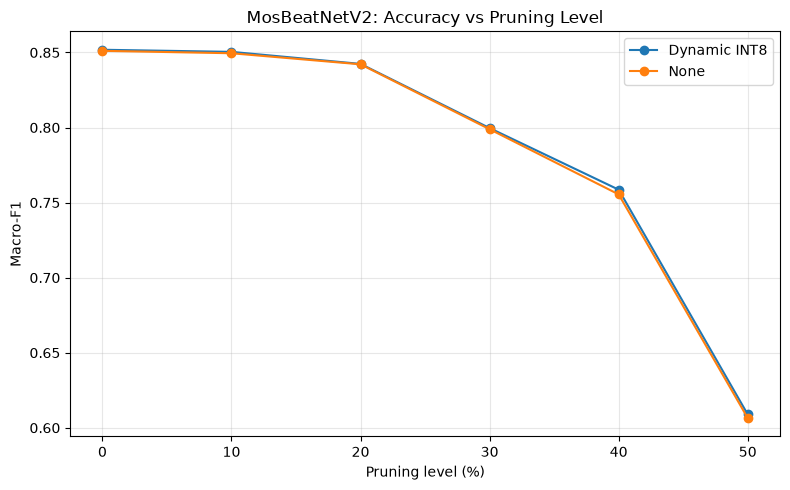

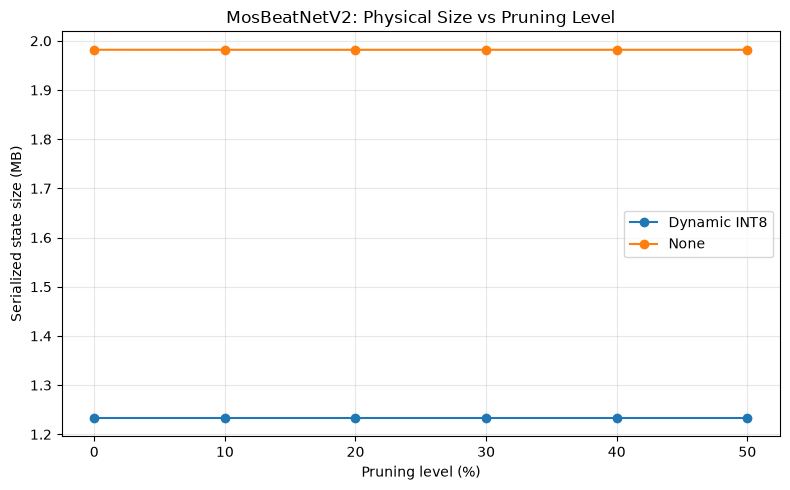

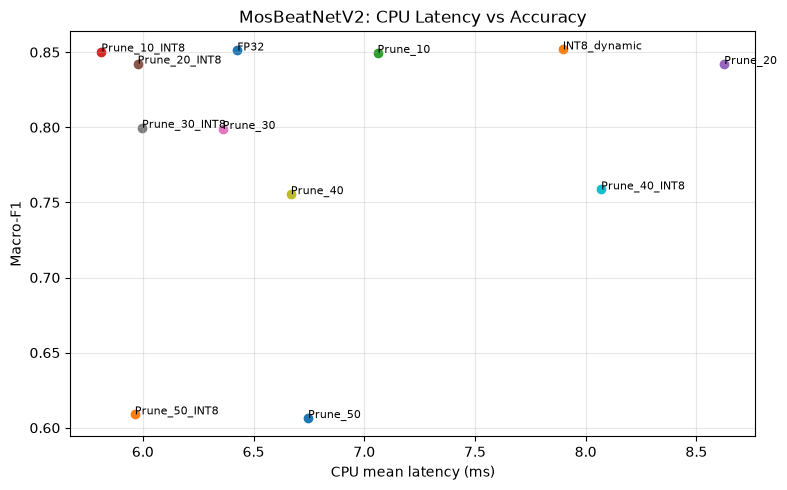

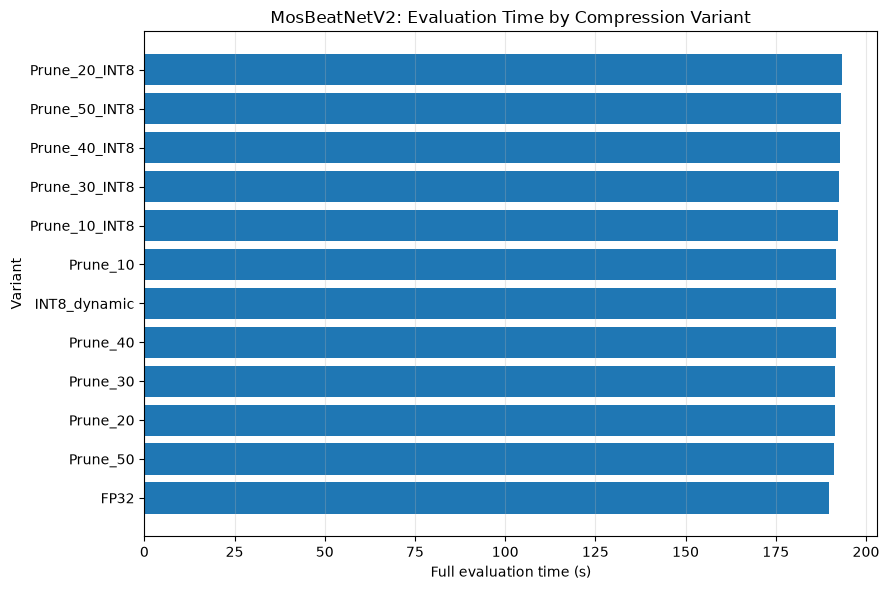

In [16]:
plot_df = final_df.copy()

# Plot 1: pruning level vs Macro-F1
plt.figure(figsize=(8, 5))

for quantization, group in plot_df.groupby("Quantization"):
    group = group.sort_values("Pruning (%)")
    plt.plot(
        group["Pruning (%)"],
        group["Macro-F1"],
        marker="o",
        label=quantization,
    )

plt.xlabel("Pruning level (%)")
plt.ylabel("Macro-F1")
plt.title("MosBeatNetV2: Accuracy vs Pruning Level")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Plot 2: pruning level vs physical state size
plt.figure(figsize=(8, 5))

for quantization, group in plot_df.groupby("Quantization"):
    group = group.sort_values("Pruning (%)")
    plt.plot(
        group["Pruning (%)"],
        group["State Size (MB)"],
        marker="o",
        label=quantization,
    )

plt.xlabel("Pruning level (%)")
plt.ylabel("Serialized state size (MB)")
plt.title("MosBeatNetV2: Physical Size vs Pruning Level")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Plot 3: latency vs Macro-F1
plt.figure(figsize=(8, 5))

for _, row in plot_df.iterrows():
    plt.scatter(
        row["CPU Mean (ms)"],
        row["Macro-F1"],
    )
    plt.text(
        row["CPU Mean (ms)"],
        row["Macro-F1"],
        row["Variant"],
        fontsize=8,
    )

plt.xlabel("CPU mean latency (ms)")
plt.ylabel("Macro-F1")
plt.title("MosBeatNetV2: CPU Latency vs Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Plot 4: full evaluation time
time_df = plot_df.sort_values("Full Eval Time (s)")

plt.figure(figsize=(9, 6))
plt.barh(
    time_df["Variant"],
    time_df["Full Eval Time (s)"],
)

plt.xlabel("Full evaluation time (s)")
plt.ylabel("Variant")
plt.title("MosBeatNetV2: Evaluation Time by Compression Variant")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 17. How to interpret the results

Use the final table and plots together:

- **Prunable Sparsity (%)**: fraction of prunable weights that became zero.
- **Effective Param Reduction (%)**: logical reduction caused by zeroed weights.
- **State Size (MB)**: physical serialized state size measured in RAM.
- **Size Reduction (%)**: actual storage reduction relative to FP32.
- **CPU Mean (ms)** and **Speedup (x)**: single-sample CPU inference behavior.
- **Full Eval Time (s)**: wall-clock time to evaluate all configured environments.
- **Macro-F1 / F1 Change**: accuracy trade-off.

A flat FP32-pruning size curve is expected for dense unstructured pruning.

If INT8 reduces state size while pruning alone does not, that is a meaningful result rather than an error.


## Recommended run order

1. Set `CHECKPOINT_PATH` if necessary.
2. Run all cells.
3. Check the output-shape table.
4. Check the benchmark table for sparsity, size, and latency.
5. Check per-environment Macro-F1 for compression-specific failures.
6. Use the final trade-off table and four plots for thesis interpretation.

No compression results are exported to disk by this notebook.
